## Germany Day-Ahead Power Market Exploration for BESS Arbitrage

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bess_analytics.data.loader import load_prices

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)


**Business question**: Can hourly German power-price dynamics support simple battery arbitrage strategies? The purpose of this notebook is to identify recurring market features such as intraday spreads, weekday effects, and negative-price events that could create monetizable storage opportunities.

---

**Why it matters**: Battery value depends on when the market rewards charging and discharging. If the price series contains repeatable low-price and high-price windows, a battery can potentially shift energy across time and earn arbitrage revenue, subject to efficiency and state-of-charge constraints.

---

**Deliverables**: This notebook provides market diagnostics, time-based price structure, and a short list of strategy hypotheses that will be tested in the backtest notebook.

### Load data    

In [4]:
df = load_prices("../src/bess_analytics/data/raw/Germany.csv")
df.head()

/var/folders/3x/jns0_g1d0hz0j981mhlv522h0000gn/T/ipykernel_89996/3427113324.py:1: UserWarning: Source data has 2 missing hour(s). Rows inserted with NaN price.
  df = load_prices("../src/bess_analytics/data/raw/Germany.csv")


,timestamp_utc,country,iso3_code,timestamp_local,price_eur_mwh
0,2015-01-01 00:00:00+00:00,Germany,DEU,2015-01-01 01:00:00,22.34
1,2015-01-01 01:00:00+00:00,Germany,DEU,2015-01-01 02:00:00,22.34
2,2015-01-01 02:00:00+00:00,Germany,DEU,2015-01-01 03:00:00,22.34
3,2015-01-01 03:00:00+00:00,Germany,DEU,2015-01-01 04:00:00,22.34
4,2015-01-01 04:00:00+00:00,Germany,DEU,2015-01-01 05:00:00,22.34


### Dataset overview

In [ ]:
# Set timestamp as index and sort by time
df = df.set_index("timestamp_utc").sort_index()

In [ ]:
# Basic data overview
print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())
print("Missing prices:", df["price_eur_mwh"].isna().sum())
print("Negative-price hours:", (df["price_eur_mwh"] < 0).sum())

df["price_eur_mwh"].describe()

Rows: 99934
Start: 2015-01-01 00:00:00+00:00
End: 2026-05-26 21:00:00+00:00
Missing prices: 2
Negative-price hours: 2439


count    99932.000000
mean        73.796913
std         79.677087
min       -372.420000
25%         30.690000
50%         46.430000
75%         93.702500
max        867.850000
Name: price_eur_mwh, dtype: float64

This dataset contains German hourly electricity prices from 2015-01-01 00:00:00+00:00 to 2026-05-26 21:00:00+00:00, with 99,934 rows, 2 missing prices, and 2,439 negative-price hours.

In [ ]:
# Missing price analysis
print(df[df["price_eur_mwh"].isna()])

                  timestamp_utc  country iso3_code timestamp_local  \
99310 2026-04-30 22:00:00+00:00  Germany       DEU             NaT   
99311 2026-04-30 23:00:00+00:00  Germany       DEU             NaT   

       price_eur_mwh  
99310            NaN  
99311            NaN  


**Observations**:
- The dataset is large enough for meaningful historical analysis and simple backtesting. Missing data is minimal, while negative-price events are common enough to be strategically important for storage dispatch.

---

In [ ]:
# Create local time features
df["hour_of_day"] = df["timestamp_local"].dt.hour
df["day_of_week"] = df["timestamp_local"].dt.dayofweek
df["day_name"] = df["timestamp_local"].dt.day_name()
df["is_weekend"] = df["day_of_week"] >= 5

### Price behavior over time

This section examines the long-run evolution of hourly prices and highlights visually important periods of volatility and structural change.



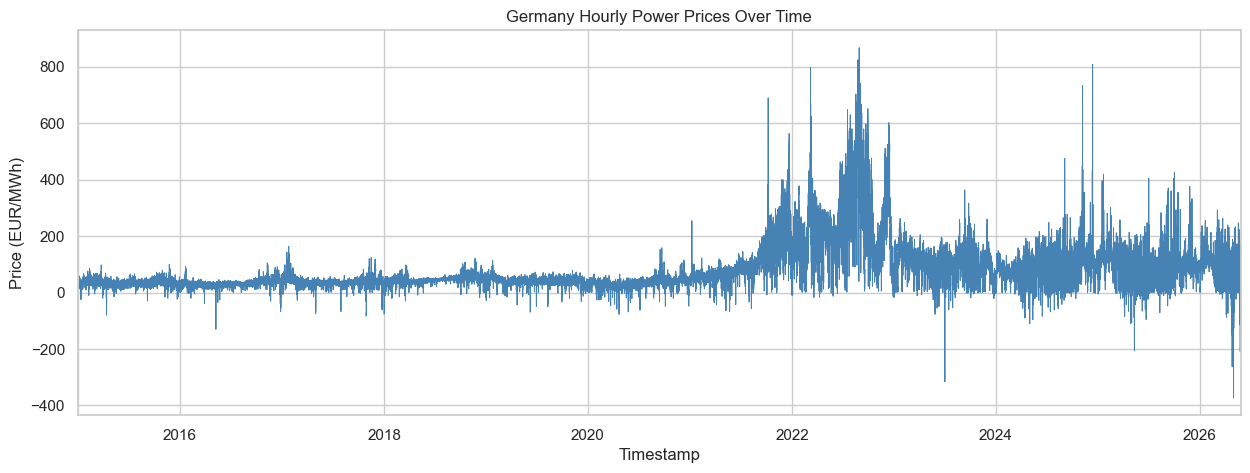

In [ ]:
# Plot the price time series
fig, ax = plt.subplots(figsize=(15, 5))
df["price_eur_mwh"].plot(ax=ax, linewidth=0.7, color="steelblue")
ax.set_title("Germany Hourly Power Prices Over Time")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price (EUR/MWh)")
plt.show()

- The full-series chart shows a long, structurally changing market with major volatility spikes around 2021–2023 and renewed volatility afterward

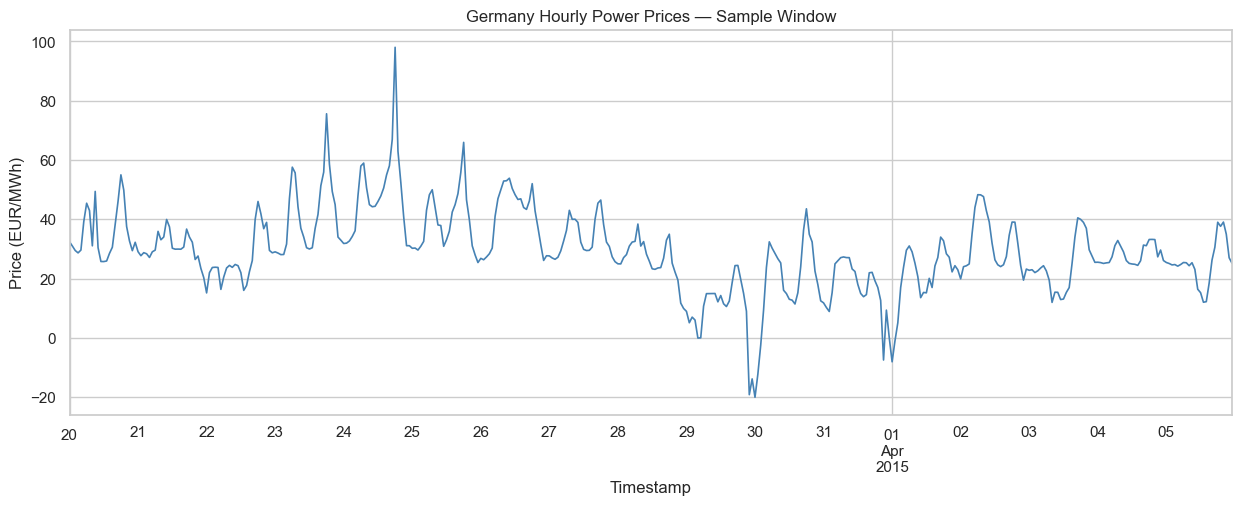

In [ ]:
# Zoom in on a specific time window
sample = df.loc["2015-03-20":"2015-04-05"]

fig, ax = plt.subplots(figsize=(15, 5))
sample["price_eur_mwh"].plot(ax=ax, linewidth=1.2, color="steelblue")
ax.set_title("Germany Hourly Power Prices — Sample Window")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price (EUR/MWh)")
plt.show()

**Observations**:
- The long-run series shows major structural shifts in volatility and price level. A shorter sample window helps isolate the short-horizon spread behavior that matters most for battery arbitrage.

### Distribution and tail behavior
Battery arbitrage is sensitive not only to average prices but also to the distribution of price outcomes, especially negative-price hours and extreme spikes.

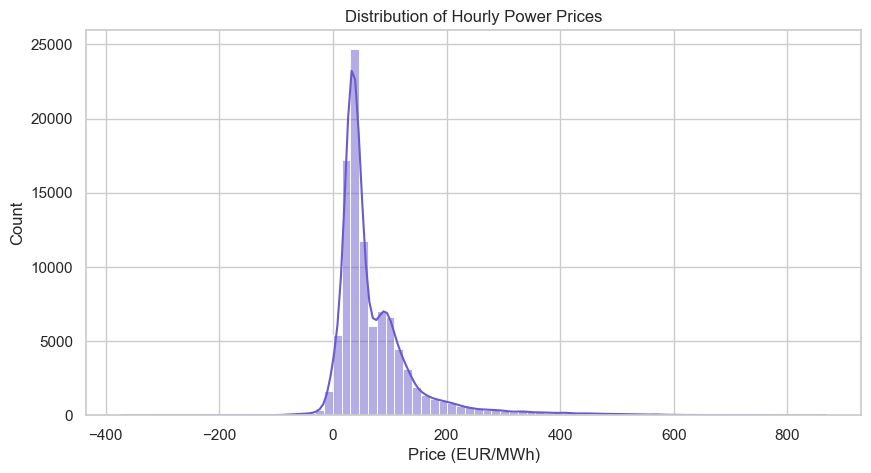

In [ ]:
# Plot the price distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["price_eur_mwh"], bins=80, kde=True, ax=ax, color="slateblue")
ax.set_title("Distribution of Hourly Power Prices")
ax.set_xlabel("Price (EUR/MWh)")
ax.set_ylabel("Count")
plt.show()

0.01     -9.7900
0.05      9.1555
0.25     30.6900
0.50     46.4300
0.75     93.7025
0.95    218.1870
0.99    430.2800
Name: price_eur_mwh, dtype: float64


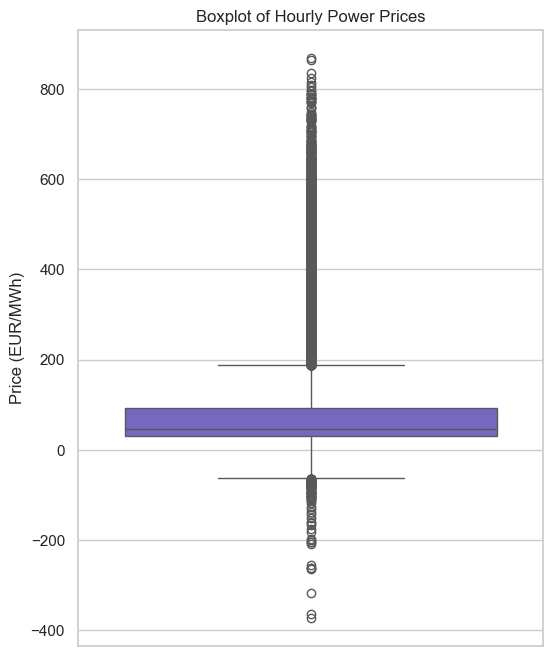

In [23]:
# Optional quantile summary or boxplot
print(df["price_eur_mwh"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# boxplot to visualize outliers
fig, ax = plt.subplots(figsize=(6, 8))
sns.boxplot(y=df["price_eur_mwh"], ax=ax, color="slateblue")
ax.set_title("Boxplot of Hourly Power Prices")
ax.set_ylabel("Price (EUR/MWh)")
plt.show()


**Observations**:
- The price distribution is right-skewed and includes a material negative tail. This combination suggests both charging opportunities during depressed-price periods and strong value capture during occasional high-price windows.

---

### Negative-price event window

Negative-price events are one of the clearest monetization opportunities for storage assets, because the battery can be paid to charge and then discharge later at higher prices.

- The histogram confirms that prices are strongly right-skewed, while the highlighted negative-price points show that sub-zero hours are not rare edge cases but a recurring feature of the sample

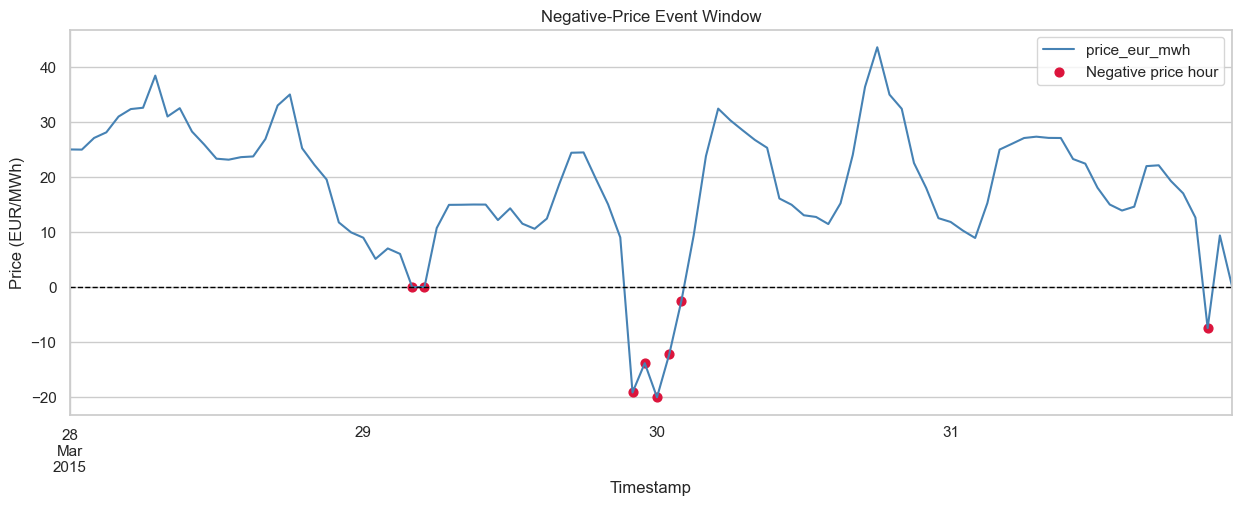

In [ ]:
# Zoom in on the negative-price event window
zoom = df.loc["2015-03-28":"2015-03-31"].copy()
negative_zoom = zoom["price_eur_mwh"] < 0

fig, ax = plt.subplots(figsize=(15, 5))
zoom["price_eur_mwh"].plot(ax=ax, linewidth=1.5, color="steelblue")
ax.scatter(
    zoom.index[negative_zoom],
    zoom.loc[negative_zoom, "price_eur_mwh"],
    color="crimson",
    s=40,
    label="Negative price hour",
)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Negative-Price Event Window")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.show()

- The event window confirms that negative prices appear in clustered episodes rather than as isolated noise. This supports testing a strategy that explicitly charges whenever prices fall below zero.

### Intraday and weekly structure

A storage strategy should reflect repeated market structure, not just isolated events. This section looks at whether hourly and weekly average profiles are stable enough to inform simple rule-based dispatch.


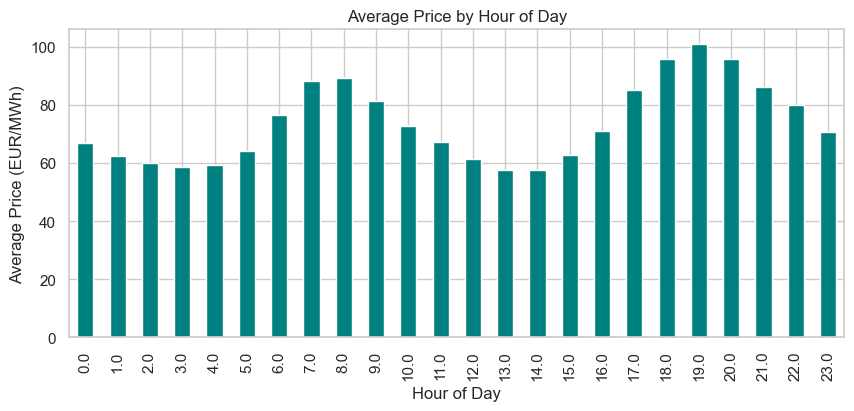

In [ ]:
# Analyze average price by hour of day
hourly_profile = df.groupby("hour_of_day")["price_eur_mwh"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_profile.plot(kind="bar", ax=ax, color="teal")
ax.set_title("Average Price by Hour of Day")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Price (EUR/MWh)")
plt.show()

- The hour-of-day plot shows a pronounced evening premium, peaking around 19:00, and lower average prices in the overnight to early-afternoon range, which is exactly the kind of intraday spread pattern a simple battery arbitrage strategy can target.
- Average prices rise sharply into the evening, suggesting that a simple rule-based arbitrage strategy could target charging in lower-price early hours and discharging during the evening peak.

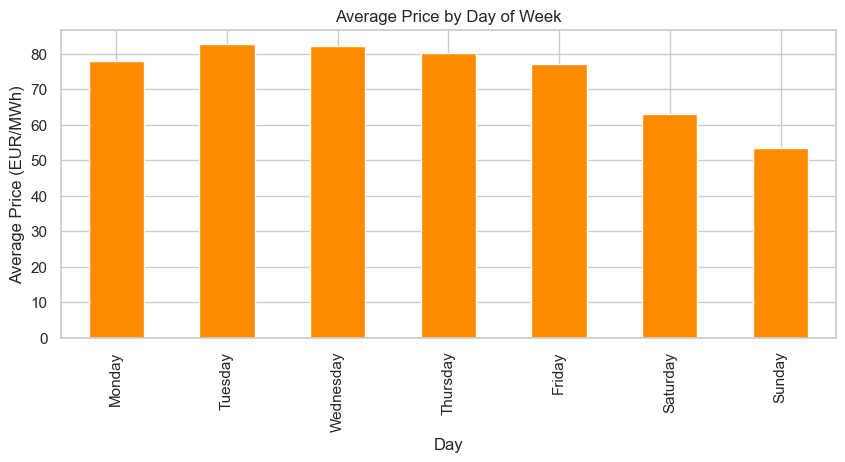

In [ ]:
# Analyze average price by day of week
dow_profile = df.groupby("day_name")["price_eur_mwh"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
)

fig, ax = plt.subplots(figsize=(10, 4))
dow_profile.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Average Price by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Average Price (EUR/MWh)")
plt.show()

- The day-of-week chart shows weekdays, especially Tuesday and Wednesday, trading materially above weekends, with Sunday the lowest, which gives you a second useful regime dimension for analysis.

### Conclusion

- The German hourly price series contains meaningful intraday variation and occasional negative-price events, making it suitable for a battery arbitrage case study.
- Negative prices are already visible in the dataset, which is especially relevant for BESS charging logic.
- Derived features such as local hour-of-day and day-of-week provide a first basis for rule-based dispatch strategies and later KPI segmentation.